In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

rfm = pd.read_csv("../data/processed/rfm_data.csv")
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,524,10,327.86,1
1,12347.0,35,7,3598.29,0
2,12348.0,244,4,353.16,0
3,12349.0,14,3,2787.09,0
4,12350.0,305,1,294.40,1


In [25]:
#Creating churn label, if a customer is inactive >90days = churn
rfm["churn"] = rfm["Recency"].apply(lambda x: 1 if x>90 else 0)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,churn
0,12346.0,524,10,327.86,1,1
1,12347.0,35,7,3598.29,0,0
2,12348.0,244,4,353.16,0,1
3,12349.0,14,3,2787.09,0,0
4,12350.0,305,1,294.40,1,1


In [26]:
rfm["churn"].value_counts()

churn
1    2892
0    2746
Name: count, dtype: int64

In [27]:
x = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["churn"]

In [28]:
# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [29]:
#scaling 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
#Model Train (Logistic Regression)
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
# Making predictions
y_pred = model.predict(X_test)

In [32]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9902482269503546

Confusion Matrix:
[[546   0]
 [ 11 571]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       546
           1       1.00      0.98      0.99       582

    accuracy                           0.99      1128
   macro avg       0.99      0.99      0.99      1128
weighted avg       0.99      0.99      0.99      1128



<Axes: xlabel='churn', ylabel='count'>

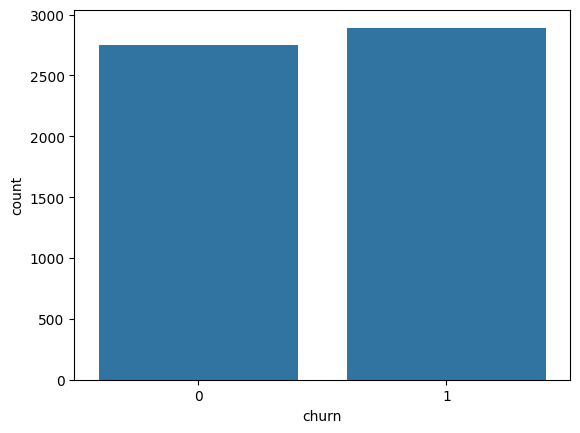

In [36]:
sns.countplot(x=rfm["churn"])